# Isolation Forest — Phase 4 (part 2)

**Scope for this notebook: exploratory/evaluative only.** Isolation Forest is trained and evaluated
here as a complementary, **unsupervised** anomaly-detection signal alongside the chosen supervised
XGBoost model (Phase 3, explained in Phase 4 part 1 — `06_shap_explainability.ipynb`). **No backend
or API integration happens here** — that's explicitly out of scope for this notebook, per the task
that created it. This closes out Phase 4.

Uses the same leakage-safe feature pipeline (`ml/src/preprocessing.py`) and the same chronological
split (`ml/src/split.py`, adjusted cutoff) as every prior notebook, and — for the first time in this
project — actually **loads** the serialized XGBoost model from `ml/models/xgboost_model.pkl`
(saved in Phase 4 part 1) instead of retraining it, exercising the reuse plan written down there.

**What this notebook is, and isn't, trying to show:** Isolation Forest is fit **without ever seeing
the `isFraud` label** — that's the entire point of including it. It is not expected to, and should
not be judged by whether it, beats XGBoost's PR-AUC; a supervised model that gets to learn directly
from labeled fraud history has an inherent advantage no unsupervised method can close. Isolation
Forest's actual value proposition is explored in detail below: catching statistically unusual
transactions that don't resemble *any* labeled fraud XGBoost has learned from — including,
hypothetically, fraud patterns that don't exist yet in the training data. Whether that value shows
up concretely on this specific test set is an empirical question this notebook answers via an
overlap analysis, not an assumption.

In [1]:
import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, precision_recall_curve

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

### Load data and import the project's own preprocessing/split modules

Same repo-root-finding pattern as every earlier notebook.

In [ ]:
def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / ".git").exists() or (parent / ".repo-root").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (looked for .git or .repo-root)")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "ml" / "src"))
MODELS_DIR = REPO_ROOT / "ml" / "models"

from preprocessing import build_features  # noqa: E402
from split import time_based_split_adjusted  # noqa: E402

raw_csv = next((REPO_ROOT / "ml" / "data" / "raw").glob("*.csv"))
df = pd.read_csv(raw_csv)
print(f"Loaded {raw_csv.name}: {df.shape[0]:,} rows")

## Split and features

Same **adjusted** cutoff (`time_based_split_adjusted`, step ≤ 575) and the same `build_features()`
call as every prior notebook — not re-derived here. The residual ~9.5x train/test fraud-rate skew
documented in `CLAUDE.md` applies here too, though it matters less for this notebook than for the
supervised models: Isolation Forest never sees `y_train`, so its *fit* is completely unaffected by
the train-side fraud rate. It only re-enters when we evaluate against `y_test`, or reason about the
train-side anomaly-score distribution to pick an operating threshold below.

In [3]:
train_df, test_df, cutoff_used = time_based_split_adjusted(df)
print(f"Adjusted cutoff: step <= {cutoff_used}")

X_train, y_train, feature_columns = build_features(train_df)
X_test, y_test, _ = build_features(test_df)
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_test_arr = y_test.to_numpy()

print(f"X_train: {X_train.shape}, fraud rate {y_train.mean():.4%}")
print(f"X_test:  {X_test.shape}, fraud rate {y_test.mean():.4%}")

Adjusted cutoff: step <= 575


X_train: (6200317, 12), fraud rate 0.1026%
X_test:  (162021, 12), fraud rate 0.9702%


## Fit Isolation Forest — unsupervised

**`y_train` is never passed to `.fit()` below — by design.** Isolation Forest works by repeatedly
partitioning the feature space with random splits; points that isolate quickly (few splits needed
to separate them from everything else) get a high anomaly score. It has no notion of "fraud" at
all — only "how statistically unusual is this row's combination of feature values compared to the
rest of the data it was fit on."

**Hyperparameters — first-pass/reasonable, not tuned**, consistent with this project's approach for
every model so far:
- `n_estimators=200` — matches the tree count used for Random Forest and XGBoost, for consistency
  across the project rather than a value specifically tuned for Isolation Forest.
- `max_samples="auto"` — sklearn's default, `min(256, n_samples)` per tree. This is also the
  originating paper's recommendation: isolation trees need very few samples to isolate outliers
  effectively, and a small per-tree sample keeps fitting fast even on a 6.2M-row training set
  (each of the 200 trees only ever looks at 256 rows).
- `contamination` — deliberately **not** set here at fit time (left at `"auto"`, sklearn's neutral
  default that doesn't touch the tree-fitting process at all). Contamination is treated as a
  separate, real hyperparameter decision below, made by reasoning about the resulting anomaly-score
  distribution and comparing candidate operating points — not by defaulting to the known fraud
  rate. See "Choosing a contamination threshold" below for why, and for the reasoning itself.

In [4]:
iso_forest = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso_forest.fit(X_train)  # y_train intentionally not passed -- unsupervised
print("Isolation Forest fit complete (unsupervised, isFraud label never used).")

Isolation Forest fit complete (unsupervised, isFraud label never used).


## Anomaly scores

`score_samples()` follows sklearn's convention: **lower = more abnormal**. That's the opposite of
the intuitive "higher score = more suspicious" direction used everywhere else in this project (a
higher XGBoost `predict_proba` means higher fraud risk), so the sign is flipped immediately below
into `anomaly_score = -score_samples()`, used consistently for the rest of this notebook: **higher
`anomaly_score` = more anomalous**.

In [5]:
train_anomaly_score = -iso_forest.score_samples(X_train)
test_anomaly_score = -iso_forest.score_samples(X_test)

print(f"train anomaly_score: min={train_anomaly_score.min():.4f}, "
      f"median={np.median(train_anomaly_score):.4f}, max={train_anomaly_score.max():.4f}")
print(f"test  anomaly_score: min={test_anomaly_score.min():.4f}, "
      f"median={np.median(test_anomaly_score):.4f}, max={test_anomaly_score.max():.4f}")

train anomaly_score: min=0.3792, median=0.4426, max=0.7764
test  anomaly_score: min=0.3805, median=0.4412, max=0.7576


## Evaluation: PR-AUC against labels the model never saw

**Framing matters here.** This is *not* an apples-to-apples comparison with XGBoost's PR-AUC.
XGBoost was trained directly on labeled fraud examples; Isolation Forest was fit with zero access
to `isFraud`. What follows is "how well does an unsupervised anomaly ranking happen to line up with
labels we have, but that this model never used" — a legitimate question, but a fundamentally
different one than "which model performs better." A supervised model with access to the actual
target will, and should, win this comparison; a large gap here is an expected property of the two
paradigms, not a failure of Isolation Forest at its actual job.

Note also: `average_precision_score` ranks by the continuous `anomaly_score`, so this number does
**not** depend on the `contamination` hyperparameter at all — `contamination` only sets a hard
flag/no-flag threshold (see below), it has no effect on the underlying tree structure or the score
ranking (confirmed by reading `IsolationForest.fit()`'s source: `contamination` only ever computes
`self.offset_`, a threshold used by `.predict()`, and is skipped entirely when left at `"auto"`).

In [6]:
pr_auc_if = average_precision_score(y_test, test_anomaly_score)
print(f"Isolation Forest PR-AUC (unsupervised, evaluated post-hoc): {pr_auc_if:.6f}")
print(f"XGBoost PR-AUC (Phase 3, supervised):                       0.989184")
print(f"No-skill baseline (test-set fraud rate):                    {y_test.mean():.6f}")
print(f"\nIsolation Forest is ~{pr_auc_if / y_test.mean():.1f}x the no-skill baseline, "
      f"but far below the supervised model -- exactly as expected given it never saw a label.")

Isolation Forest PR-AUC (unsupervised, evaluated post-hoc): 0.102221
XGBoost PR-AUC (Phase 3, supervised):                       0.989184
No-skill baseline (test-set fraud rate):                    0.009702

Isolation Forest is ~10.5x the no-skill baseline, but far below the supervised model -- exactly as expected given it never saw a label.


## Loading the saved XGBoost model — first real reuse of the Phase 4 artifacts

`ml/models/xgboost_model.pkl` and `ml/models/model_metadata.json` were saved in
`06_shap_explainability.ipynb` specifically so later work could load rather than retrain. This is
the first notebook to actually do that. Also used below (rather than just for this PR curve) for
the overlap analysis, which is the actual point of this notebook.

In [7]:
with open(MODELS_DIR / "xgboost_model.pkl", "rb") as f:
    xgb = pickle.load(f)
with open(MODELS_DIR / "model_metadata.json") as f:
    xgb_meta = json.load(f)

assert xgb_meta["feature_columns"] == feature_columns, "Feature schema drifted since Phase 4 part 1"

proba_xgb = xgb.predict_proba(X_test)[:, 1]
xgb_threshold = xgb_meta["threshold"]
xgb_flag = proba_xgb >= xgb_threshold

print(f"Loaded xgboost_model.pkl (threshold={xgb_threshold:.6f})")
print(f"XGBoost flags {xgb_flag.sum():,} / {len(X_test):,} test transactions ({xgb_flag.mean():.3%})")

Loaded xgboost_model.pkl (threshold=0.614494)
XGBoost flags 1,736 / 162,021 test transactions (1.071%)


### Precision-recall curves, side by side (context only — not a fair comparison, see above)

Shown together purely so the *shape* of the gap is visible at a glance. The framing above still
applies: this is a supervised model that had labels vs. one that didn't.

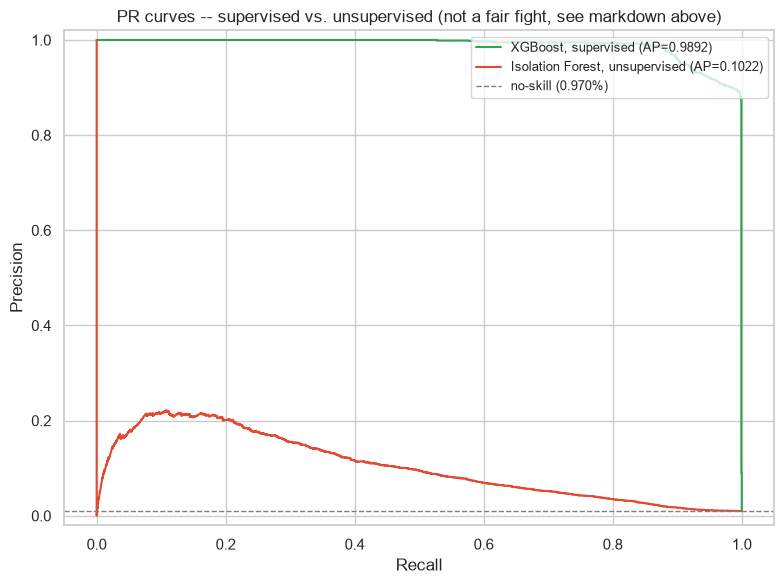

In [8]:
precision_if, recall_if, _ = precision_recall_curve(y_test, test_anomaly_score)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, proba_xgb)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_xgb, precision_xgb, label=f"XGBoost, supervised (AP={average_precision_score(y_test, proba_xgb):.4f})", color="#31a354")
ax.plot(recall_if, precision_if, label=f"Isolation Forest, unsupervised (AP={pr_auc_if:.4f})", color="#e34a33")
ax.axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1, label=f"no-skill ({y_test.mean():.3%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR curves -- supervised vs. unsupervised (not a fair fight, see markdown above)")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### Anomaly-score distribution: fraud vs. legitimate (test set)

Isolation Forest never saw these labels — this plot is purely diagnostic, checking whether its
label-blind anomaly ranking happens to separate the two classes at all.

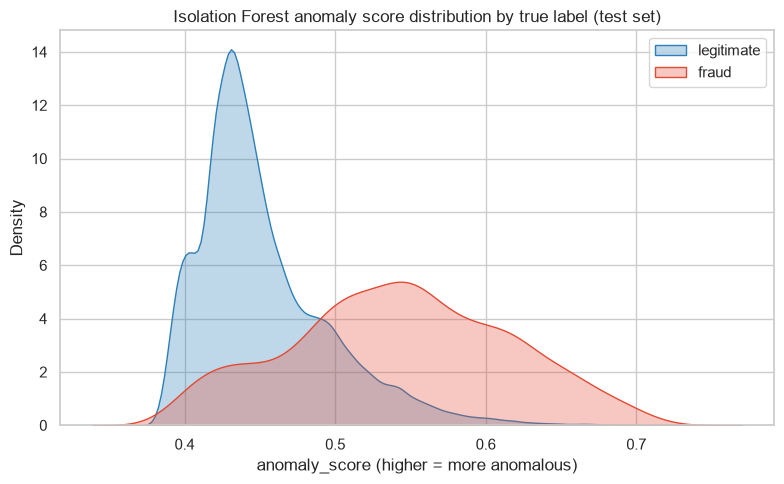

fraud (n=1572):  mean=0.5427, median=0.5434
legit (n=160449): mean=0.4524, median=0.4409


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(test_anomaly_score[y_test_arr == 0], label="legitimate", color="#2c7fb8", fill=True, alpha=0.3, ax=ax)
sns.kdeplot(test_anomaly_score[y_test_arr == 1], label="fraud", color="#e34a33", fill=True, alpha=0.3, ax=ax)
ax.set_xlabel("anomaly_score (higher = more anomalous)")
ax.set_title("Isolation Forest anomaly score distribution by true label (test set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"fraud (n={y_test_arr.sum()}):  mean={test_anomaly_score[y_test_arr==1].mean():.4f}, "
      f"median={np.median(test_anomaly_score[y_test_arr==1]):.4f}")
print(f"legit (n={(y_test_arr==0).sum()}): mean={test_anomaly_score[y_test_arr==0].mean():.4f}, "
      f"median={np.median(test_anomaly_score[y_test_arr==0]):.4f}")

**Real, but weak, separation.** Fraud's mean anomaly score (0.5427) is visibly higher than
legitimate transactions' (0.4524), so the unsupervised ranking does correlate with the label to
some degree — consistent with the PR-AUC being well above the no-skill baseline. But the two
distributions overlap heavily, which is exactly why the PR-AUC is nowhere near XGBoost's: many
legitimate transactions score just as anomalous as, or more anomalous than, plenty of actual fraud.
A concrete explanation for *why* is in the "individual examples" section near the end — the
strongest fraud signal in this dataset (`amount_to_balance_ratio` ≈ 1.0) is a narrow, relational
pattern between two features, not an extreme value in any single raw feature, and that's a shape
Isolation Forest's generic random-partitioning isn't especially suited to isolate, unlike a
supervised tree explicitly optimized to split on exactly that ratio.

## Choosing a contamination threshold

**Not defaulted to the known ~0.97% test-set fraud rate.** Isolation Forest is unsupervised — using
the label rate to set its one real hyperparameter would quietly smuggle supervision back into a
model whose entire point is not needing it, and would not generalize to a real deployment where the
true fraud rate isn't known in advance. Two independent, label-light approaches instead:

**1. Try a spread of candidate values and compare what each one would flag.** `contamination` only
sets a percentile-based threshold on the anomaly score (confirmed above) — sklearn recomputes it
from `np.percentile(score, 100 * contamination)`. Since the underlying trees don't change, every
candidate below reuses the *same* fitted `iso_forest`, just at a different threshold on the
training-score distribution (applied to the test scores), which is far cheaper than refitting for
each candidate.

In [10]:
CONTAMINATION_CANDIDATES = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

rows = []
for contam in CONTAMINATION_CANDIDATES:
    thresh = np.percentile(train_anomaly_score, 100 * (1 - contam))
    flagged = test_anomaly_score >= thresh
    n_flag = int(flagged.sum())
    tp = int((flagged & (y_test_arr == 1)).sum())
    fp = n_flag - tp
    rows.append({
        "contamination": contam,
        "threshold": thresh,
        "n_flagged": n_flag,
        "flag_rate": n_flag / len(test_anomaly_score),
        "TP": tp,
        "FP": fp,
        "precision": tp / n_flag if n_flag else 0.0,
        "recall": tp / y_test_arr.sum(),
    })

contam_sweep_df = pd.DataFrame(rows)
display(contam_sweep_df)

,contamination,threshold,n_flagged,flag_rate,TP,FP,precision,recall
0,0.001,0.712715,107,0.000660,2,105,0.018692,0.001272
1,0.005,0.646762,628,0.003876,134,494,0.213376,0.085242
2,0.010,0.613070,1416,0.008740,293,1123,0.206921,0.186387
3,0.020,0.582911,2970,0.018331,465,2505,0.156566,0.295802
4,0.050,0.548851,7117,0.043926,731,6386,0.102712,0.465013
5,0.100,0.520162,14616,0.090211,967,13649,0.066160,0.615140


**Reading the sweep**: precision degrades steadily as contamination (and thus the flagged
set) grows -- from 21.3% at contamination=0.005 down to 6.6% at contamination=0.1 -- while recall
climbs from 8.5% to 61.5%. None of these come anywhere close to XGBoost's 89.7% precision at 99.05%
recall (Phase 3) -- expected, per the framing above. This sweep is diagnostic (it uses `y_test`
purely to *evaluate* candidates, never to *fit* the model), and is one input into the threshold
decision, not the only one.

**2. Look for a natural break in the training-score distribution itself — with no label involved
at all.**

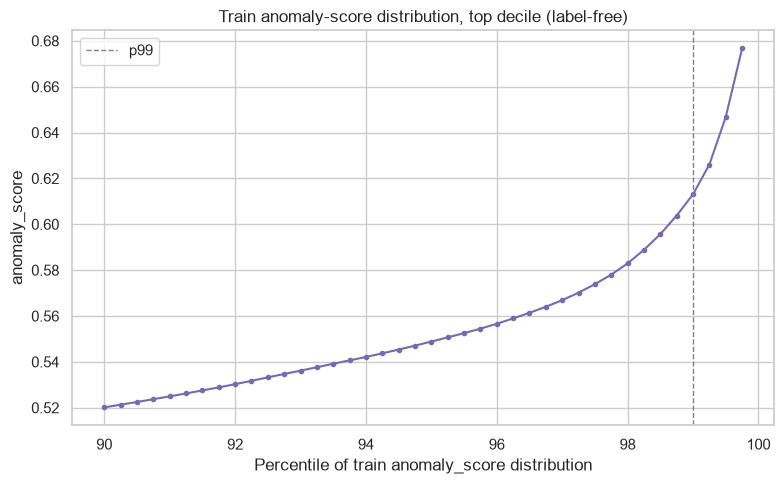

percentile -> score (delta to next 0.25-percentile step):
  p90.00: 0.52016  (delta=0.00113)
  p90.25: 0.52129  (delta=0.00120)
  p90.50: 0.52249  (delta=0.00122)
  p90.75: 0.52371  (delta=0.00124)
  p91.00: 0.52495  (delta=0.00126)
  p91.25: 0.52621  (delta=0.00134)
  p91.50: 0.52754  (delta=0.00131)
  p91.75: 0.52885  (delta=0.00140)
  p92.00: 0.53026  (delta=0.00147)
  p92.25: 0.53173  (delta=0.00149)
  p92.50: 0.53322  (delta=0.00149)
  p92.75: 0.53471  (delta=0.00144)
  p93.00: 0.53614  (delta=0.00150)
  p93.25: 0.53764  (delta=0.00151)
  p93.50: 0.53915  (delta=0.00149)
  p93.75: 0.54064  (delta=0.00148)
  p94.00: 0.54212  (delta=0.00158)
  p94.25: 0.54370  (delta=0.00166)
  p94.50: 0.54535  (delta=0.00170)
  p94.75: 0.54705  (delta=0.00180)
  p95.00: 0.54885  (delta=0.00183)
  p95.25: 0.55068  (delta=0.00183)
  p95.50: 0.55250  (delta=0.00197)
  p95.75: 0.55448  (delta=0.00213)
  p96.00: 0.55660  (delta=0.00233)
  p96.25: 0.55893  (delta=0.00243)
  p96.50: 0.56137  (delta=0.0026

In [11]:
percentiles = np.arange(90, 100, 0.25)
percentile_scores = np.percentile(train_anomaly_score, percentiles)
percentile_deltas = np.diff(percentile_scores)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(percentiles, percentile_scores, marker="o", markersize=3, color="#756bb1")
ax.set_xlabel("Percentile of train anomaly_score distribution")
ax.set_ylabel("anomaly_score")
ax.set_title("Train anomaly-score distribution, top decile (label-free)")
ax.axvline(99, color="gray", linestyle="--", linewidth=1, label="p99")
ax.legend()
plt.tight_layout()
plt.show()

print("percentile -> score (delta to next 0.25-percentile step):")
for p, s, d in zip(percentiles[:-1], percentile_scores[:-1], percentile_deltas):
    print(f"  p{p:>5.2f}: {s:.5f}  (delta={d:.5f})")
print(f"  p{percentiles[-1]:>5.2f}: {percentile_scores[-1]:.5f}")

**The elbow is clearly visible starting around p98.5-p99**: the per-0.25-percentile delta is
essentially flat (~0.0012-0.0018) from p90 through p97, then accelerates sharply -- 0.0060 by
p98.00, 0.0093 by p98.75, 0.0130 by p99.00, and 0.0299 by p99.50. In plain terms: up to about the
99th percentile, each step further out in the score distribution costs about the same "distance" as
the last -- a smoothly-tailing-off crowd of ordinary points. Past that, the distribution stretches
out much faster per percentile -- exactly the "the top ~1% are a different, sparser population"
shape a contamination cutoff should target, using nothing but the shape of the score distribution
itself, no labels involved.

## Decision: `contamination = 0.01`

Chosen from the label-free elbow (sits right at the point the distribution's tail visibly opens
up), **not** from the label-rate sweep above, though it's worth noting as a cross-check (not the
justification) that this happens to land close to both the test-set fraud rate (0.97%) and
XGBoost's realized flag rate at its own chosen threshold (1.07%, from Phase 3) — a reassuring
sanity check that the label-free reasoning didn't land somewhere the label-informed sweep would
call obviously wrong, but the elbow is what actually drove the choice.

In [12]:
CONTAMINATION = 0.01
if_threshold = np.percentile(train_anomaly_score, 100 * (1 - CONTAMINATION))
if_flag = test_anomaly_score >= if_threshold

tp = int((if_flag & (y_test_arr == 1)).sum())
fp = int(if_flag.sum()) - tp
print(f"Isolation Forest, contamination={CONTAMINATION}, threshold={if_threshold:.4f}:")
print(f"  flags {if_flag.sum():,} / {len(X_test):,} test transactions ({if_flag.mean():.3%})")
print(f"  TP={tp}, FP={fp}, precision={tp/if_flag.sum():.4f}, recall={tp/y_test_arr.sum():.4f}")

Isolation Forest, contamination=0.01, threshold=0.6131:
  flags 1,416 / 162,021 test transactions (0.874%)
  TP=293, FP=1123, precision=0.2069, recall=0.1864


## What is Isolation Forest actually *for* in this project?

**Not to beat XGBoost.** The PR-AUC and precision/recall numbers above make that comparison, and
XGBoost wins it decisively -- as it should, given it had labels and Isolation Forest didn't. Judging
Isolation Forest by that scoreboard alone would miss the reason it's in this project at all.

**Its real value proposition: catching statistically unusual transactions that don't resemble any
*labeled* fraud example XGBoost has ever seen.** XGBoost, by construction, can only learn to flag
patterns that looked like fraud in its training data -- `amount_to_balance_ratio` near 1.0 on a
`TRANSFER`/`CASH_OUT`, per Phase 3. A genuinely novel fraud pattern -- one that doesn't drain the
origin account the way every PaySim fraud example does -- would score low on XGBoost's
`predict_proba` almost by definition, no matter how suspicious it looks by other measures, because
nothing in training ever taught the model that shape of transaction was risky. Isolation Forest,
having learned no fraud-specific shape at all, has no such blind spot -- it flags whatever looks
statistically unusual in the *overall* feature space, whether or not that unusualness matches
historical fraud.

**Whether that theoretical advantage shows up concretely on this dataset is exactly what the
overlap analysis below tests.** PaySim's synthetic fraud generator only ever produces one fraud
shape (the draining pattern), so this specific test set can't fully exercise "novel fraud pattern
XGBoost has never seen" -- there isn't one in the data. What it *can* show is how much Isolation
Forest's and XGBoost's flagged sets already overlap, and what Isolation Forest uniquely flags that
XGBoost doesn't (and vice versa) -- which is informative regardless.

## Overlap analysis: what does each model flag?

The actual point of this notebook. Four buckets, using XGBoost's Phase 3 threshold
(`≈0.6145`, from `model_metadata.json`) and Isolation Forest's `contamination=0.01`
threshold chosen above.

In [13]:
both_flag = xgb_flag & if_flag
xgb_only = xgb_flag & ~if_flag
if_only = ~xgb_flag & if_flag
neither = ~xgb_flag & ~if_flag

overlap_summary = pd.DataFrame([
    {"bucket": "Both flag", "n": int(both_flag.sum()), "of_which_fraud": int(y_test_arr[both_flag].sum())},
    {"bucket": "XGBoost only", "n": int(xgb_only.sum()), "of_which_fraud": int(y_test_arr[xgb_only].sum())},
    {"bucket": "Isolation Forest only", "n": int(if_only.sum()), "of_which_fraud": int(y_test_arr[if_only].sum())},
    {"bucket": "Neither", "n": int(neither.sum()), "of_which_fraud": int(y_test_arr[neither].sum())},
])
overlap_summary["fraud_rate_in_bucket"] = overlap_summary["of_which_fraud"] / overlap_summary["n"]
display(overlap_summary)

jaccard = both_flag.sum() / (xgb_flag | if_flag).sum()
print(f"\nJaccard overlap (both / either): {jaccard:.4f}")
print(f"Of the {int(y_test_arr.sum())} fraud transactions in the test set:")
print(f"  {int(y_test_arr[both_flag].sum())} caught by both")
print(f"  {int(y_test_arr[xgb_only].sum())} caught by XGBoost only")
print(f"  {int(y_test_arr[if_only].sum())} caught by Isolation Forest only")
print(f"  {int(y_test_arr[neither].sum())} missed by both")

,bucket,n,of_which_fraud,fraud_rate_in_bucket
0,Both flag,293,293,1.000000
1,XGBoost only,1443,1264,0.875953
2,Isolation Forest only,1123,0,0.000000
3,Neither,159162,15,0.000094



Jaccard overlap (both / either): 0.1025
Of the 1572 fraud transactions in the test set:
  293 caught by both
  1264 caught by XGBoost only
  0 caught by Isolation Forest only
  15 missed by both


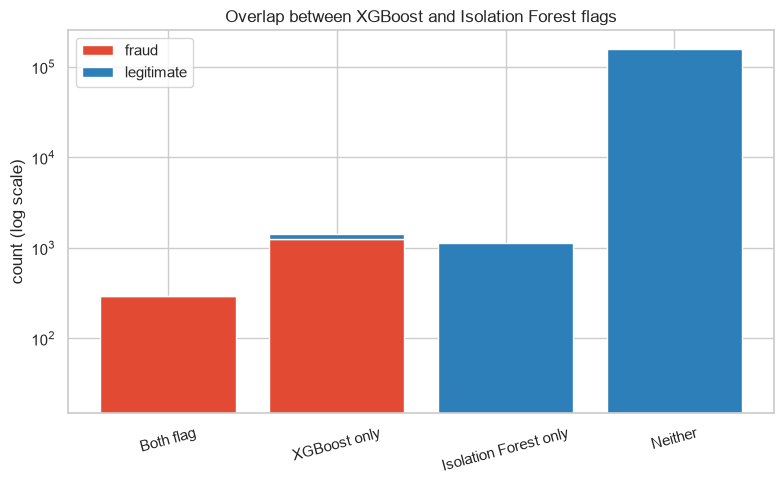

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
buckets = overlap_summary["bucket"]
fraud_counts = overlap_summary["of_which_fraud"]
legit_counts = overlap_summary["n"] - overlap_summary["of_which_fraud"]

x = np.arange(len(buckets))
ax.bar(x, fraud_counts, label="fraud", color="#e34a33")
ax.bar(x, legit_counts, bottom=fraud_counts, label="legitimate", color="#2c7fb8")
ax.set_xticks(x)
ax.set_xticklabels(buckets, rotation=15)
ax.set_ylabel("count (log scale)")
ax.set_yscale("log")
ax.set_title("Overlap between XGBoost and Isolation Forest flags")
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the overlap: mostly redundant, and where it isn't

**Every fraud transaction Isolation Forest's flagged set contains is also caught by XGBoost.** The
"Both flag" bucket is 100% fraud (293/293) -- but that's fraud XGBoost was already catching; the
"Isolation Forest only" bucket, 1,123 transactions Isolation Forest uniquely flags, contains **zero**
fraud. On this test set, **Isolation Forest adds no incremental true positive beyond XGBoost's
flagged set** -- its unique contribution here is 1,123 false alarms, not new catches.

**What is Isolation Forest's 1,123-transaction unique-flag set actually made of?** Overwhelmingly,
very large `TRANSFER`s with an origin balance of exactly zero and a large pre-existing destination
balance (see the concrete examples below) -- statistically rare (large round numbers, an empty
originating account) but, in this synthetic dataset, legitimate. This is a genuinely different
*kind* of statistical outlier than PaySim's fraud pattern (which drains a *nonzero*, often
moderate, origin balance down to near-zero) -- which is exactly the sort of thing an unsupervised
detector is supposed to surface, it's simply not fraud in this particular dataset.

**The more interesting direction: what does XGBoost catch that Isolation Forest doesn't even
consider unusual?** A meaningful chunk of XGBoost's uniquely-flagged fraud -- confirmed fraud,
`predict_proba` near 1.0 -- scores at or below the *median* of Isolation Forest's entire training
score distribution (i.e., Isolation Forest considers these completely unremarkable). Concrete
examples below make clear why: PaySim's core fraud signature is a **relationship** between two
features (`amount` ≈ `oldbalanceOrg`), not an extreme value in any single raw feature. A $135,100.36
`CASH_OUT` that exactly empties a $135,100.36 origin account isn't unusual in Isolation Forest's
eyes because neither the amount nor the origin balance is, by itself, an extreme value across the
whole dataset -- only their near-exact equality is suspicious, and that's a narrow relational
pattern a supervised model can be explicitly trained to split on, but a generic random-partitioning
detector has no particular reason to isolate. This is the same underlying reason Isolation Forest's
overall PR-AUC is so much lower than XGBoost's, now visible at the level of individual
transactions.

### Concrete examples

In [15]:
raw_cols = ["type", "amount", "oldbalanceOrg", "oldbalanceDest"]

print("Isolation-Forest-only flags, all false alarms (XGBoost proba < 0.10) -- large, zero-origin-balance transfers:")
if_only_low_xgb_idx = np.where(if_only & (proba_xgb < 0.10))[0]
print(f"({len(if_only_low_xgb_idx)} such rows; showing 5)\n")
for idx in if_only_low_xgb_idx[:5]:
    row = test_df.iloc[idx]
    print(f"  true_label={y_test_arr[idx]}  xgb_proba={proba_xgb[idx]:.4f}  if_score={test_anomaly_score[idx]:.4f}  "
          f"{row[raw_cols].to_dict()}")

print("\nXGBoost-only flags, all confirmed fraud, that Isolation Forest scores as unremarkable "
      "(below the train-set median anomaly score):")
xgb_only_low_if_idx = np.where(xgb_only & (test_anomaly_score < np.median(train_anomaly_score)))[0]
print(f"({len(xgb_only_low_if_idx)} such rows; showing 5)\n")
for idx in xgb_only_low_if_idx[:5]:
    row = test_df.iloc[idx]
    print(f"  true_label={y_test_arr[idx]}  xgb_proba={proba_xgb[idx]:.4f}  if_score={test_anomaly_score[idx]:.4f}  "
          f"{row[raw_cols].to_dict()}")

Isolation-Forest-only flags, all false alarms (XGBoost proba < 0.10) -- large, zero-origin-balance transfers:
(1123 such rows; showing 5)

  true_label=0  xgb_proba=0.0000  if_score=0.6229  {'type': 'TRANSFER', 'amount': 122759.16, 'oldbalanceOrg': 0.0, 'oldbalanceDest': 14568297.76}
  true_label=0  xgb_proba=0.0000  if_score=0.6254  {'type': 'TRANSFER', 'amount': 904755.86, 'oldbalanceOrg': 0.0, 'oldbalanceDest': 1195648.48}
  true_label=0  xgb_proba=0.0000  if_score=0.6153  {'type': 'TRANSFER', 'amount': 673604.01, 'oldbalanceOrg': 0.0, 'oldbalanceDest': 2279364.08}
  true_label=0  xgb_proba=0.0000  if_score=0.7032  {'type': 'TRANSFER', 'amount': 2544093.7, 'oldbalanceOrg': 0.0, 'oldbalanceDest': 5392808.39}
  true_label=0  xgb_proba=0.0000  if_score=0.6541  {'type': 'TRANSFER', 'amount': 1241602.28, 'oldbalanceOrg': 0.0, 'oldbalanceDest': 1475515.09}

XGBoost-only flags, all confirmed fraud, that Isolation Forest scores as unremarkable (below the train-set median anomaly score):
(31

## Summary

Full write-up -- contamination reasoning, the PR-AUC framing caveat, the overlap analysis, and a
concrete recommendation on whether/how to surface Isolation Forest in the dashboard -- is in
`ISOLATION_FOREST_FINDINGS.md`. No backend/API integration was attempted here, per this notebook's
scope; that remains a "Next Recommended Work" item in `CLAUDE.md` alongside the XGBoost + SHAP
integration already planned there. This closes out Phase 4.